<a href="https://colab.research.google.com/github/aasutoshz/Distribution-Grid-Optimal-Power-Flow-DOPF/blob/main/IEEE%20PESGM%202026/Branchflow_DOPF_Models/SOCP/SOCP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Second-Order Cone Programming Formulation for Optimal Power Flow (OPF)

This code implements a generic branch-flow-based three-phase Optimal Power Flow (OPF) formulation using Second-Order Cone Programming (SOCP). The model is derived by approximating the bus-impedance matrix and relaxing the nonlinear quadratic equality constraints into convex second-order cone constraints.

The development and implementation of this code, test network are contribution of:\
**Aashutosh Neupane**, **Florida International University (FIU), USA**

This Python code is built up on previous MATLAB live script (developed and tested on the first 20 nodes of the IEEE 123 Node Test Feeder). The contributors of the MATLAB livescripts were:

**Anamika Dubey**, **Washington State University (WSU), USA**\
**Sukumar Kamalasadan**, **University of North Carolina at Charlotte (UNCC), USA**\
**Sumit Paudyal**, **Florida International University (FIU), USA**

If you have any questions and comments kindly email aneup003@fiu.edu

## 1. Import Required Libraries

In [ ]:
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import cvxpy as cp
from collections import deque
import os

## 2. Load the Network Data

In [2]:
# Set up file paths and load Excel workbook
from google.colab import files
uploaded = files.upload()
excel_file = next(iter(uploaded.keys()))
script_dir = os.getcwd()
excel_file = os.path.join(script_dir, excel_file)
print(f"Reading network data from: {excel_file}")
wb = openpyxl.load_workbook(excel_file, data_only=True)


TypeError: 'NoneType' object is not subscriptable

## 3. Read Parameters Sheet and Extract Key Parameters

In [ ]:
param_sheet = wb['Parameters']
param_dict = {}
for row in param_sheet.iter_rows(min_row=1, values_only=True):
    if row[0] is not None:
        param_dict[str(row[0])] = row[1]
slack_bus = int(param_dict['slack_bus'])
baseMVA = float(param_dict['baseMVA_VA'])
baseV = float(param_dict['baseV'])
baseZ = baseV**2 / baseMVA
Vmin_pu = float(param_dict['Vmin_pu'])
Vmax_pu = float(param_dict['Vmax_pu'])
dg_oversize = float(param_dict['DG_oversize_factor'])
LMP = float(param_dict['LMP']) #Load Multiplier
PMP = float(param_dict['PMP']) #Dg Multiplier

print(f'Slack bus: {slack_bus}, baseMVA: {baseMVA/1e6} MVA, baseV: {baseV:.2f} V')

## 4. Read Branches Sheet and Extract Branch Data

In [ ]:
branch_sheet = wb['Branches']
branch_raw = []
for row in branch_sheet.iter_rows(min_row=2, values_only=True):
    if row[0] is not None:
        branch_raw.append([float(v) if v is not None else 0.0 for v in row])
branch_raw = np.array(branch_raw)
brs = branch_raw.shape[0]
node1 = branch_raw[:, 0].astype(int)
node2 = branch_raw[:, 1].astype(int)
all_buses = sorted(set(node1.tolist() + node2.tolist()))
tnode = len(all_buses)
nb = tnode
print(f'Number of buses: {all_buses}, {tnode} (from branch data)')
bus_to_idx = {bus: i for i, bus in enumerate(all_buses)}

## 5. Build R, X Arrays and Load Data

In [ ]:
Rdiag = np.zeros((brs, 3))
Xdiag = np.zeros((brs, 3))
for brid in range(brs):
    #Builds the Diagonal Imepdnce matrix, makes SOCP phase decoupled
    Rdiag[brid, :] = [branch_raw[brid, 2], branch_raw[brid, 5], branch_raw[brid, 7]]
    Rdiag[brid, :] /= baseZ
    Xdiag[brid, :] = [branch_raw[brid, 8], branch_raw[brid, 11], branch_raw[brid, 13]]
    Xdiag[brid, :] /= baseZ

## 6. Load Sheet Data for Loads and DG

In [ ]:
load_sheet = wb['Loads']
Pload = np.zeros((tnode, 3))
Qload = np.zeros((tnode, 3))
for row in load_sheet.iter_rows(min_row=2, values_only=True):
    if row[0] is None:
        continue
    bus = int(row[0])
    idx = bus_to_idx[bus]
    Pload[idx, 0] = LMP * float(row[1]) * 1000 / baseMVA
    Pload[idx, 1] = LMP * float(row[2]) * 1000 / baseMVA
    Pload[idx, 2] = LMP * float(row[3]) * 1000 / baseMVA
    Qload[idx, 0] = LMP * float(row[4]) * 1000 / baseMVA
    Qload[idx, 1] = LMP * float(row[5]) * 1000 / baseMVA
    Qload[idx, 2] = LMP * float(row[6]) * 1000 / baseMVA

dg_sheet = wb['DG']
PPv = np.zeros((tnode, 3))
for row in dg_sheet.iter_rows(min_row=2, values_only=True):
    if row[0] is None:
        continue
    bus = int(row[0])
    idx = bus_to_idx[bus]
    PPv[idx, 0] = PMP * float(row[1]) * 1000 / baseMVA
    PPv[idx, 1] = PMP * float(row[2]) * 1000 / baseMVA
    PPv[idx, 2] = PMP * float(row[3]) * 1000 / baseMVA
Sinv = PPv * dg_oversize
Qinv = np.sqrt(Sinv**2 - PPv**2)



## 7. Build Topology

In [ ]:
phase_avail = {bus: [] for bus in all_buses}
phase_avail[slack_bus] = [1, 2, 3]

queue = deque([slack_bus])
visited = {slack_bus}
while queue:
    bus = queue.popleft()
    for brid in range(brs):
        if node1[brid] == bus:
            child = node2[brid]
            if child not in visited:
                visited.add(child)
                br_phases = [p for p in range(1, 4)
                             if Rdiag[brid, p - 1] > 1e-10 or Xdiag[brid, p - 1] > 1e-10]
                phase_avail[child] = sorted(set(phase_avail[bus]) & set(br_phases))
                queue.append(child)

max_out = max(np.sum(node1 == bus) for bus in all_buses)
incbr = np.zeros(tnode, dtype=int)
outbr = np.zeros((tnode, max_out), dtype=int)

for bus in all_buses:
    idx = bus_to_idx[bus]
    in_idxs = np.where(node2 == bus)[0]
    incbr[idx] = (in_idxs[0] + 1) if len(in_idxs) > 0 else 0
    out_idxs = np.where(node1 == bus)[0]
    for col, oidx in enumerate(out_idxs):
        outbr[idx, col] = oidx + 1


## 8. Print Data Summary

In [ ]:
#Description of the slack bus and the number of the available phases
print(f'Data loaded: {nb} buses, {brs} branches')
print(f'Phase availability (sample): Bus {slack_bus} -> phases {phase_avail[slack_bus]}')

## 9. SOCP OPF Model- General Problem Formulation

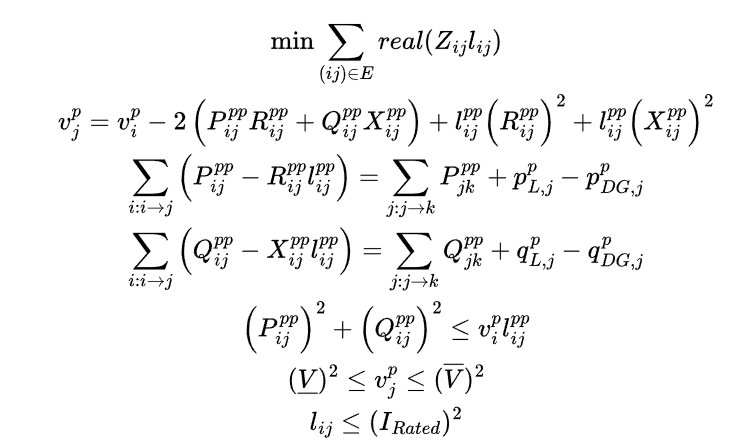
![alt text](https://github.com/aasutoshz/Distribution-Grid-Optimal-Power-Flow-DOPF/blob/main/IEEE%20PESGM%202026/Branchflow_DOPF_Models/SOCP/SOCP.png?raw=1)


## 10. Build and solve SOCP DOPF Model

In [ ]:

def solve_opf(Q_control: bool):
    # Variables
    V   = cp.Variable((tnode, 3), name="V")     # V[bus, ph] = |v|²  (squared voltage magnitude)
    ell = cp.Variable((brs, 3), name="ell")       # ell[branch, ph] = |i|² (squared current magnitude)
    Pbr = cp.Variable((brs, 3), name="Pbr")    # Pbr[branch, ph] = real power flow on branch
    Qbr = cp.Variable((brs, 3), name="Qbr")     # Qbr[branch, ph] = reactive power flow on branch
    PSlack = cp.Variable(3, name="PSlack")      # QPv[bus, ph] = reactive power injected by inverter
    QSlack = cp.Variable(3, name="QSlack")   # slack bus active power (per phase)
    QPv = cp.Variable((tnode, 3), name="QPv")   # slack bus reactive power (per phase)
    Vnom=1
    constraints = []

    # ell >= 0
    constraints.append(ell >= 0)

    # Slack-bus voltage (use bus_to_idx for arbitrary bus numbering)
    slack_idx = bus_to_idx[slack_bus]
    for ph in range(3):
        constraints.append(V[slack_idx, ph] == Vnom**2)


    for nid_0, nid_1 in enumerate(all_buses):
        inc = incbr[nid_0]
        out_brs = [b for b in outbr[nid_0, :] if b != 0]

        if inc == 0:
            # Slack bus
            for ph in range(3):
                constraints.append(
                    PSlack[ph] == cp.sum(cp.hstack([Pbr[b - 1, ph] for b in out_brs])))
                constraints.append(
                    QSlack[ph] == cp.sum(cp.hstack([Qbr[b - 1, ph] for b in out_brs])))
        elif len(out_brs) == 0:
            # Leaf bus
            for ph in range(3):
                constraints.append(
                    Pbr[inc - 1, ph] - ell[inc - 1, ph] * Rdiag[inc - 1, ph]
                    == Pload[nid_0, ph] - PPv[nid_0, ph])
                constraints.append(
                    Qbr[inc - 1, ph] - ell[inc - 1, ph] * Xdiag[inc - 1, ph]
                    == Qload[nid_0, ph] - QPv[nid_0, ph])
        else:
            # Interior bus
            for ph in range(3):
                constraints.append(
                    Pbr[inc - 1, ph] - ell[inc - 1, ph] * Rdiag[inc - 1, ph]
                    == cp.sum(cp.hstack([Pbr[b - 1, ph] for b in out_brs]))
                       + Pload[nid_0, ph] - PPv[nid_0, ph])
                constraints.append(
                    Qbr[inc - 1, ph] - ell[inc - 1, ph] * Xdiag[inc - 1, ph]
                    == cp.sum(cp.hstack([Qbr[b - 1, ph] for b in out_brs]))
                       + Qload[nid_0, ph] - QPv[nid_0, ph])

    # Inverter VAR bounds
    for nid_0 in range(tnode):
        for ph in range(3):
            if Q_control:
                constraints.append(QPv[nid_0, ph] >= -Qinv[nid_0, ph])
                constraints.append(QPv[nid_0, ph] <=  Qinv[nid_0, ph])
            else:
                constraints.append(QPv[nid_0, ph] >= 0)
                constraints.append(QPv[nid_0, ph] <= 0)


    # Voltage bounds
    for nid_0 in range(tnode):
        for ph in range(3):
            constraints.append(V[nid_0, ph] >= Vmin_pu**2)
            constraints.append(V[nid_0, ph] <= Vmax_pu**2)

    # Voltage drop (DistFlow) Linear
    for brid in range(brs):
        for ph in range(3):
            ZZ = Rdiag[brid, ph]**2 + Xdiag[brid, ph]**2
            n1_0 = bus_to_idx[node1[brid]]
            n2_0 = bus_to_idx[node2[brid]]
            constraints.append(
                V[n2_0, ph] == V[n1_0, ph]
                - 2 * Rdiag[brid, ph] * Pbr[brid, ph]
                - 2 * Xdiag[brid, ph] * Qbr[brid, ph]
                + ZZ * ell[brid, ph])

    # SOCP relaxation  ‖[2P, 2Q, ℓ−v]‖₂ ≤ ℓ+v  (phase decoupled)
    #expanding it P^2 + Q^2 <= V * ell (current magnitude squared times voltage magnitude squared), S^2=(VI*)^2
    """ cp,SOC takes the form cp.SOC(t, x) where t is a scalar variable and x is a vector variable.
    The constraint enforces that the Euclidean norm of x is less than or equal to t.
    In our case, we want to enforce that the norm of the vector [2P, 2Q, ell - V] is less than or equal to ell + V."""
    for brid in range(brs):
        for ph in range(3):
            n1_0 = bus_to_idx[node1[brid]]
            constraints.append(
                cp.SOC(
                    ell[brid, ph] + V[n1_0, ph],
                    cp.hstack([
                        2 * Pbr[brid, ph],
                        2 * Qbr[brid, ph],
                        ell[brid, ph] - V[n1_0, ph]
                    ])
                )
            )

    # Fix zero currents/flows for missing phases
    for brid in range(brs):
        child = node2[brid]
        avail = phase_avail[child]
        for ph in range(1, 4):
            if ph not in avail:
                constraints.append(ell[brid, ph - 1] == 0)
                constraints.append(Pbr[brid, ph - 1] == 0)
                constraints.append(Qbr[brid, ph - 1] == 0)



    obj = cp.Minimize(cp.sum(cp.multiply(ell, Rdiag)))

    problem = cp.Problem(obj, constraints)
    problem.solve(solver=cp.SCS, max_iters=100_000, eps_abs=1e-9, eps_rel=1e-9, verbose=False)

    status = problem.status
    obj_val = problem.value #if minimize_loss else "N/A (feasibility)"
    print(f"Status: {status}  obj = {obj_val}")

    V_val   = V.value
    L_val   = ell.value
    Pbr_val = Pbr.value
    Qbr_val = Qbr.value

    # Total loss of the system
    loss = np.sum(L_val * Rdiag)

    # SOCP gap
    gap = np.zeros((brs, 3))
    for brid in range(brs):
        for ph in range(3):
            n1_0 = bus_to_idx[node1[brid]]
            gap[brid, ph] = (Pbr_val[brid, ph]**2 + Qbr_val[brid, ph]**2
                             - V_val[n1_0, ph] * L_val[brid, ph])

    return V_val, L_val, loss, gap


# ═══════════════════════════════════════════════════════════════════════════════
#  Build the per-phase voltage display matrix (NaN for missing phases)
# ═══════════════════════════════════════════════════════════════════════════════
def build_Vval(V_val):
    Vval = np.full((tnode, 3), np.nan)
    for nid in all_buses:
        nid_0 = bus_to_idx[nid]
        for ph in phase_avail[nid]:
            Vval[nid_0, ph - 1] = abs(V_val[nid_0, ph - 1])
    return np.sqrt(Vval)  # convert V² → |V|


# ═══════════════════════════════════════════════════════════════════════════════
#  Solve both cases
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("  Case 1:  WITH DG control (minimize losses)")
print("=" * 60)
V_ctrl, L_ctrl, loss_control, gap_ctrl = solve_opf(Q_control=True)
Vval_control   = build_Vval(V_ctrl)

print("=" * 60)

# Print results
print(f"\nMax |SOCP gap| (control)   : {np.max(np.abs(gap_ctrl))}")

print(f"\nLoss with DG control   : {loss_control:.6f} p.u. = {loss_control *1000:.4f} kW")


print("\n─── Voltage Magnitudes (with DG control) ────────────")
print(f"{'Node':>6s}  {'Phase A':>10s}  {'Phase B':>10s}  {'Phase C':>10s}")
for nid_0, nid in enumerate(all_buses):
    vals = []
    for ph in range(3):
        v = Vval_control[nid_0, ph]
        vals.append("   ---   " if np.isnan(v) else f"  {v:.5f}")
    print(f"{nid:6d}  {vals[0]:>10s}  {vals[1]:>10s}  {vals[2]:>10s}")


In [ ]:
print()
print("=" * 60)
print("  Case 2:  WITHOUT DG control (power flow only)")
print("=" * 60)
V_noctrl, L_noctrl, loss_nocontrol, gap_noctrl = solve_opf(Q_control=False)

Vval_control   = build_Vval(V_ctrl)
Vval_nocontrol = build_Vval(V_noctrl)

# Print results
print(f"Max |SOCP gap| (no control): {np.max(np.abs(gap_noctrl))}")
print(f"\nLoss with DG control   : {loss_control:.6f} p.u. = {loss_control *1000:.4f} kW")
print(f"Loss without DG control: {loss_nocontrol:.6f} p.u. = {loss_nocontrol * 1000:.4f} kW")

print("\n─── Voltage Magnitudes (with DG control) ────────────")
print(f"{'Node':>6s}  {'Phase A':>10s}  {'Phase B':>10s}  {'Phase C':>10s}")
for nid_0, nid in enumerate(all_buses):
    vals = []
    for ph in range(3):
        v = Vval_control[nid_0, ph]
        vals.append("   ---   " if np.isnan(v) else f"  {v:.5f}")
    print(f"{nid:6d}  {vals[0]:>10s}  {vals[1]:>10s}  {vals[2]:>10s}")


In [ ]:
# Save the "with DG control" voltages to Excel
output_dir = os.getcwd()
os.makedirs(output_dir, exist_ok=True)
excel_out_ctrl = os.path.join(output_dir, "Voltage with DG Control (SOCP).xlsx")
wb_out_ctrl = openpyxl.Workbook()
ws_out_ctrl = wb_out_ctrl.active
ws_out_ctrl.title = "With_DG_Control"

ws_out_ctrl.append(["Node", "Phase A", "Phase B", "Phase C"])
for nid_0, nid in enumerate(all_buses):
    row_vals = [nid]
    for ph in range(3):
        v = Vval_control[nid_0, ph]
        row_vals.append(None if np.isnan(v) else float(round(v, 5)))
    ws_out_ctrl.append(row_vals)

wb_out_ctrl.save(excel_out_ctrl)
print(f"Saved Excel file: {excel_out_ctrl}")


In [ ]:
print("\n─── Saving Voltage Magnitudes (without DG control) ────────────")
print(f"{'Node':>6s}  {'Phase A':>10s}  {'Phase B':>10s}  {'Phase C':>10s}")
for nid_0, nid in enumerate(all_buses):
    vals = []
    for ph in range(3):
        v = round(Vval_nocontrol[nid_0, ph], 5)
        vals.append("   ---   " if np.isnan(v) else f"  {v:.5f}")
    print(f"{nid:6d}  {vals[0]:>10s}  {vals[1]:>10s}  {vals[2]:>10s}")

# Save the "without DG control" voltages to Excel
output_dir = os.getcwd()
os.makedirs(output_dir, exist_ok=True)
excel_out = os.path.join(output_dir, "Voltage without DG Control (SOCP).xlsx")
wb_out = openpyxl.Workbook()
ws_out = wb_out.active
ws_out.title = "Without_DG_Control"

ws_out.append(["Node", "Phase A", "Phase B", "Phase C"])
for nid_0, nid in enumerate(all_buses):
    row_vals = [nid]
    for ph in range(3):
        v = Vval_nocontrol[nid_0, ph]
        row_vals.append(None if np.isnan(v) else float(round(v, 5)))
    ws_out.append(row_vals)

wb_out.save(excel_out)
print(f"Saved Excel file: {excel_out}")


## 11. Plot Results  

In [ ]:


# Plot voltage profiles and loss comparison
buses = idx
x_labels = list(all_buses)
x_pos = np.arange(len(x_labels))
fig, axes = plt.subplots(3, 1, figsize=(18, 15), sharex=True)
phase_labels = ["Phase A", "Phase B", "Phase C"]

for idx_phase, ax in enumerate(axes):
    ax.scatter(x_pos, Vval_control[:, idx_phase], marker='o', s=15, label="with DG Q-control (SDP)")
    ax.scatter(x_pos, Vval_nocontrol[:, idx_phase], marker='x', s=15, label="without DG Q-control (SDP)")

    ax.set_ylabel(f"{phase_labels[idx_phase]} (p.u.)")
    ax.set_xlim(0, len(x_labels) - 1)
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.legend(loc="upper right", fontsize=9)
    ax.tick_params(labelsize=9)
    ax.set_ylim(0.94, 1.06)
    ax.horizontal_line = ax.axhline(0.95, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.horizontal_line = ax.axhline(1.05, color='red', linestyle='--', linewidth=1, alpha=0.7)

    ax.grid(True, linestyle='--', alpha=0.6)

axes[-1].set_xlabel("Bus")
axes[0].set_title("SDP Voltage Profile")
plt.tight_layout()
plt.savefig(os.path.join(script_dir, "sdp_voltage_profile.png"), dpi=300)
plt.show()

# Loss comparison bar chart
fig2, ax2 = plt.subplots(figsize=(5, 4))
loss_kW = [loss_control * baseMVA / 1000, loss_nocontrol * baseMVA / 1000]

bars = ax2.bar(["with DG Q-control", "without DG Q-control"], loss_kW,
               width=0.4, color=["steelblue", "orange"])
ax2.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)
ax2.set_ylabel("Power loss (kW)", fontsize=11)
ax2.set_title("SOCP: Active Power Loss Comparison")
ax2.set_ylim(0, max(loss_kW) * 1.15)
ax2.tick_params(labelsize=10)
plt.tight_layout()
plt.savefig( r"socp_loss_comparison.png", dpi=300)
plt.show()